In [1]:
# Crime Data Analysis: 2020–2024
# Jupyter Notebook IDE
# This notebook performs exploratory data analysis (EDA) on the Crime Data from 2020 to 2024 dataset.

# Objectives below 
# Inspect and clean the dataset.
# Analyse crime trends by year and month.
# Identify frequently reported crime categories.
# Compare police areas.
# Explore victim age and sex.
# Examine premises and weapon information.
# Analyse time-of-day patterns


In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

# Load the dataset
df = pd.read_csv("C:\\Users\\moats\\OneDrive - Richfield Graduate Institute of Technology\\SQL Projects\\Crime_data_from_2020_to_2024.csv.csv")
df

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Rows: 1,004,894
Columns: 28


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


## 1. Data Understanding and Cleaning

In [4]:
# Convert date columns
df["Date Rptd"] = pd.to_datetime(df["Date Rptd"], errors="coerce")
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")

# Create useful analysis columns
df["Year"] = df["DATE OCC"].dt.year
df["Month"] = df["DATE OCC"].dt.month
df["Month Name"] = df["DATE OCC"].dt.month_name()
df["Day Name"] = df["DATE OCC"].dt.day_name()

# TIME OCC is stored as HHMM
df["Hour"] = pd.to_numeric(df["TIME OCC"], errors="coerce").fillna(0).astype(int) // 100
df["Hour"] = df["Hour"].clip(0, 23)

def time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    return "Night"

df["Time Period"] = df["Hour"].apply(time_period)

print("Occurrence period:", df["DATE OCC"].min().date(), "to", df["DATE OCC"].max().date())
print("Reported period:", df["Date Rptd"].min().date(), "to", df["Date Rptd"].max().date())


C:\Users\moats\AppData\Local\Temp\ipykernel_11752\3823137974.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date Rptd"] = pd.to_datetime(df["Date Rptd"], errors="coerce")
C:\Users\moats\AppData\Local\Temp\ipykernel_11752\3823137974.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")


Occurrence period: 2020-01-01 to 2024-12-30
Reported period: 2020-01-01 to 2025-03-28


In [5]:
# Missing values and duplicates
missing = (
    df.isna().sum()
      .to_frame("Missing Values")
      .assign(Percentage=lambda x: (x["Missing Values"] / len(df) * 100).round(2))
      .sort_values("Missing Values", ascending=False)
)

display(missing.head(15))
print("Duplicate rows:", df.duplicated().sum())
print("Invalid negative victim ages:", (df["Vict Age"] < 0).sum())


,Missing Values,Percentage
Crm Cd 4,1004830,99.99
Crm Cd 3,1002580,99.77
Crm Cd 2,935740,93.12
Cross Street,850666,84.65
Weapon Desc,677678,67.44
Weapon Used Cd,677678,67.44
Mocodes,151598,15.09
Vict Descent,144643,14.39
Vict Sex,144631,14.39
Premis Desc,588,0.06


Duplicate rows: 0
Invalid negative victim ages: 137


### Cleaning approach

- Dates are converted to datetime values.
- Missing values are retained rather than automatically replacing them with zero.
- Negative victim ages are excluded from age-based statistics because they are not valid ages.
- The original dataset columns are kept so the analysis remains traceable.


## 2. Descriptive Overview

In [6]:
summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Unique crime codes",
        "Unique crime descriptions",
        "Police areas",
        "Median valid victim age",
        "Records with weapon information",
        "Records with victim sex information"
    ],
    "Value": [
        len(df),
        df["Crm Cd"].nunique(),
        df["Crm Cd Desc"].nunique(),
        df["AREA NAME"].nunique(),
        df.loc[df["Vict Age"] >= 0, "Vict Age"].median(),
        df["Weapon Desc"].notna().sum(),
        df["Vict Sex"].notna().sum()
    ]
})
display(summary)


,Metric,Value
0,Total records,1004894.0
1,Unique crime codes,140.0
2,Unique crime descriptions,140.0
3,Police areas,21.0
4,Median valid victim age,30.0
5,Records with weapon information,327216.0
6,Records with victim sex information,860263.0


## 3. Crime Trend by Year

,Number of Incidents
Year,
2020,199847
2021,209876
2022,235259
2023,232345
2024,127567


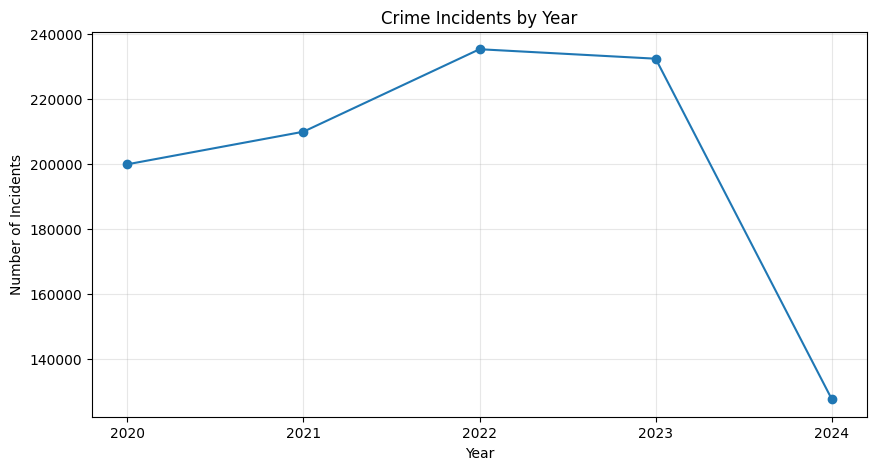

,Year-on-Year Change (%)
Year,
2020,NaN
2021,5.02
2022,12.09
2023,-1.24
2024,-45.10


In [7]:
yearly = df["Year"].value_counts().sort_index()
display(yearly.to_frame("Number of Incidents"))

plt.figure()
plt.plot(yearly.index, yearly.values, marker="o")
plt.title("Crime Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(yearly.index)
plt.grid(alpha=0.3)
plt.show()

display((yearly.pct_change() * 100).round(2).to_frame("Year-on-Year Change (%)"))


## 4. Monthly Crime Pattern

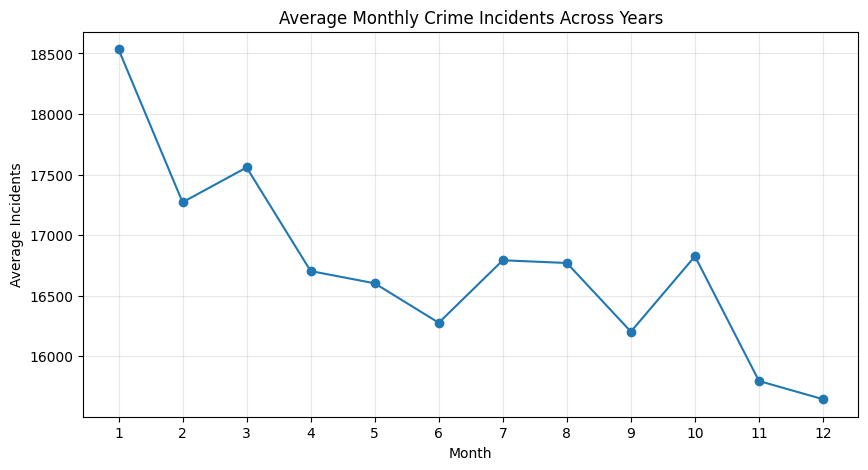

,Total Incidents
Month,
1,92675
2,86357
3,87794
4,83517
5,83011
6,81382
7,83962
8,83850
9,81015


In [8]:
monthly = df.groupby(["Year", "Month"]).size().reset_index(name="Incidents")
avg_month = monthly.groupby("Month")["Incidents"].mean()

plt.figure()
plt.plot(avg_month.index, avg_month.values, marker="o")
plt.title("Average Monthly Crime Incidents Across Years")
plt.xlabel("Month")
plt.ylabel("Average Incidents")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.show()

display(df["Month"].value_counts().sort_index().to_frame("Total Incidents"))


## 5. Most Common Crime Types

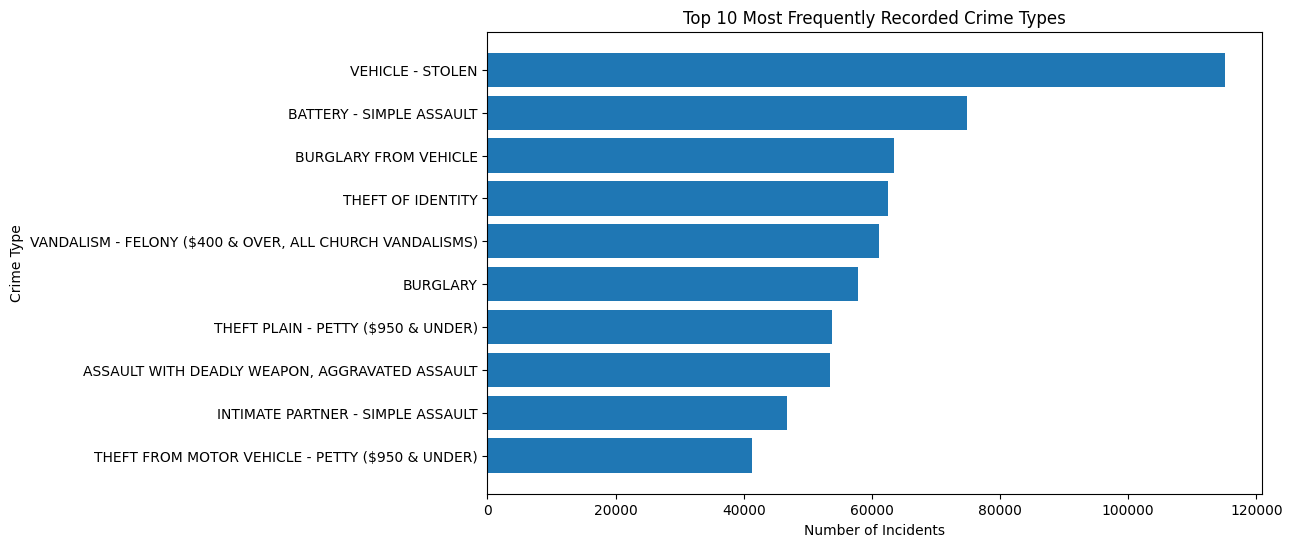

,Incidents
Crm Cd Desc,
VEHICLE - STOLEN,115184
BATTERY - SIMPLE ASSAULT,74821
BURGLARY FROM VEHICLE,63515
THEFT OF IDENTITY,62536
"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",61086
BURGLARY,57871
THEFT PLAIN - PETTY ($950 & UNDER),53716
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",53523
INTIMATE PARTNER - SIMPLE ASSAULT,46712


In [9]:
top_crimes = df["Crm Cd Desc"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_crimes.index, top_crimes.values)
plt.title("Top 10 Most Frequently Recorded Crime Types")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")
plt.show()

display(top_crimes.sort_values(ascending=False).to_frame("Incidents"))


### Insight

The most frequent crime categories represent the largest recorded incident volumes in this dataset. A useful next step is to break these categories down by area and time period rather than analysing them only at an overall level.


## 6. Crime by Police Area

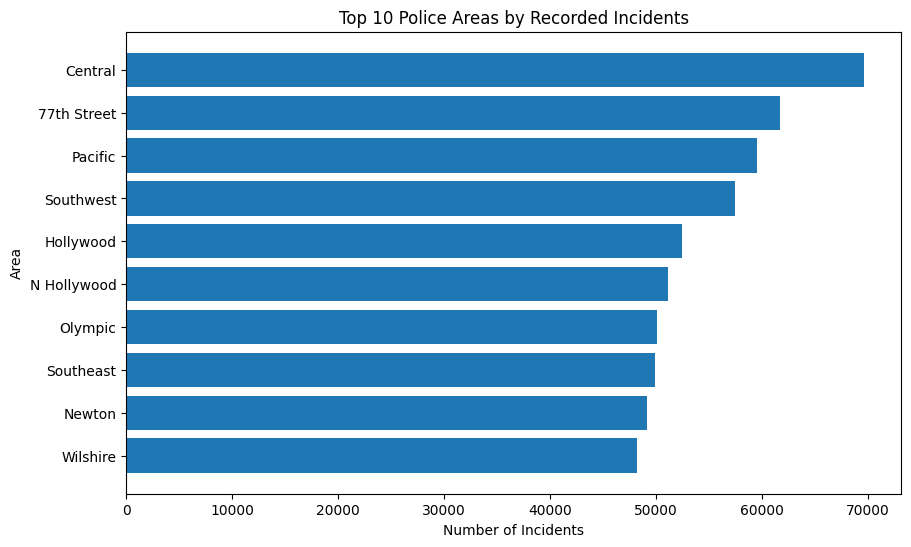

,Incidents
AREA NAME,
Central,69668
77th Street,61756
Pacific,59513
Southwest,57434
Hollywood,52429
N Hollywood,51106
Olympic,50070
Southeast,49929
Newton,49173


In [10]:
top_areas = df["AREA NAME"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_areas.index, top_areas.values)
plt.title("Top 10 Police Areas by Recorded Incidents")
plt.xlabel("Number of Incidents")
plt.ylabel("Area")
plt.show()

display(top_areas.sort_values(ascending=False).to_frame("Incidents"))


Raw incident counts are useful for understanding workload, but they should not be treated as a direct measure of crime risk because areas can differ in population, geography and activity levels.


## 7. Victim Age Analysis

Median valid victim age: 30.0
Mean valid victim age: 28.92


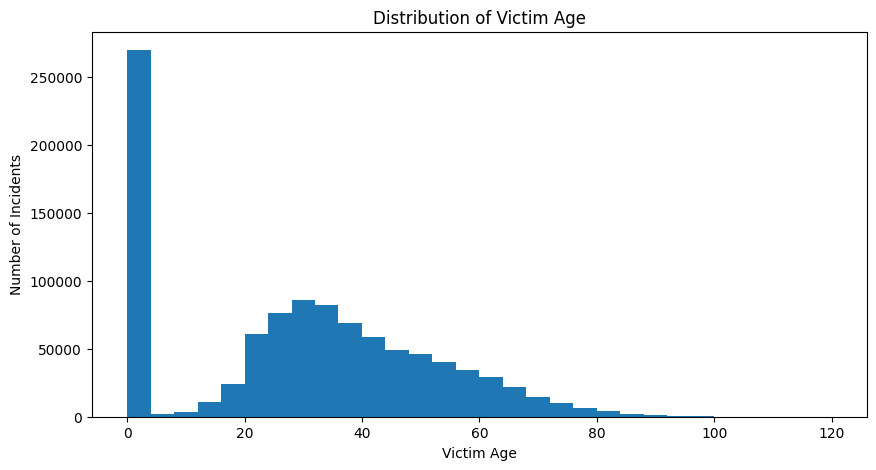

,Incidents
Victim Age Group,
0–17,294881
18–24,94949
25–34,205218
35–44,162141
45–54,112736
55–64,79458
65+,55511


In [11]:
valid_age = df.loc[df["Vict Age"] >= 0, "Vict Age"]

print("Median valid victim age:", valid_age.median())
print("Mean valid victim age:", round(valid_age.mean(), 2))

plt.figure()
plt.hist(valid_age, bins=30)
plt.title("Distribution of Victim Age")
plt.xlabel("Victim Age")
plt.ylabel("Number of Incidents")
plt.show()

bins = [-1, 17, 24, 34, 44, 54, 64, 120]
labels = ["0–17", "18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
df["Victim Age Group"] = pd.cut(df["Vict Age"].clip(lower=0), bins=bins, labels=labels)
display(df["Victim Age Group"].value_counts().reindex(labels).to_frame("Incidents"))


## 8. Victim Sex Distribution

,Incidents
Vict Sex,
M,403842
F,358553
Unknown,144631
X,97753
H,114
-,1


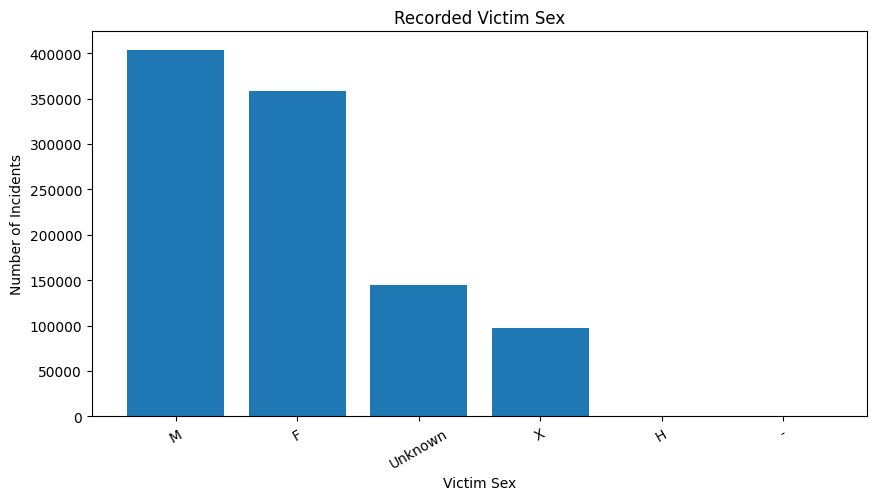

In [12]:
sex_counts = df["Vict Sex"].fillna("Unknown").value_counts()
display(sex_counts.to_frame("Incidents"))

plt.figure()
plt.bar(sex_counts.index.astype(str), sex_counts.values)
plt.title("Recorded Victim Sex")
plt.xlabel("Victim Sex")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=30)
plt.show()


## 9. Time-of-Day Analysis

,Incidents
Time Period,
Morning,227181
Afternoon,268452
Evening,230709
Night,278552


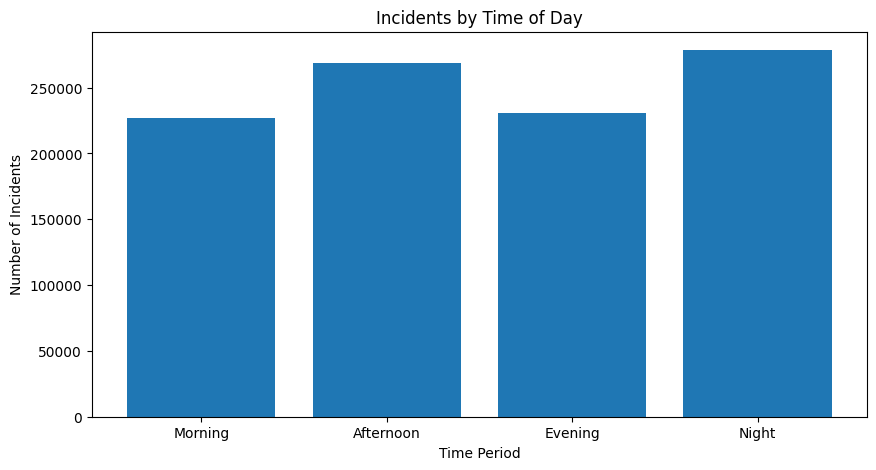

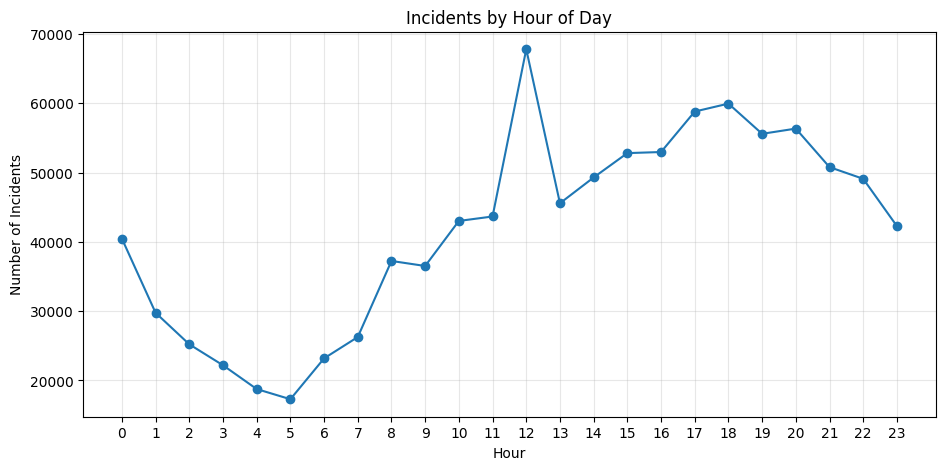

In [13]:
period_counts = df["Time Period"].value_counts().reindex(
    ["Morning", "Afternoon", "Evening", "Night"]
)
display(period_counts.to_frame("Incidents"))

plt.figure()
plt.bar(period_counts.index, period_counts.values)
plt.title("Incidents by Time of Day")
plt.xlabel("Time Period")
plt.ylabel("Number of Incidents")
plt.show()

hourly = df["Hour"].value_counts().sort_index()

plt.figure(figsize=(11, 5))
plt.plot(hourly.index, hourly.values, marker="o")
plt.title("Incidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Incidents")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()


## 10. Premise Analysis

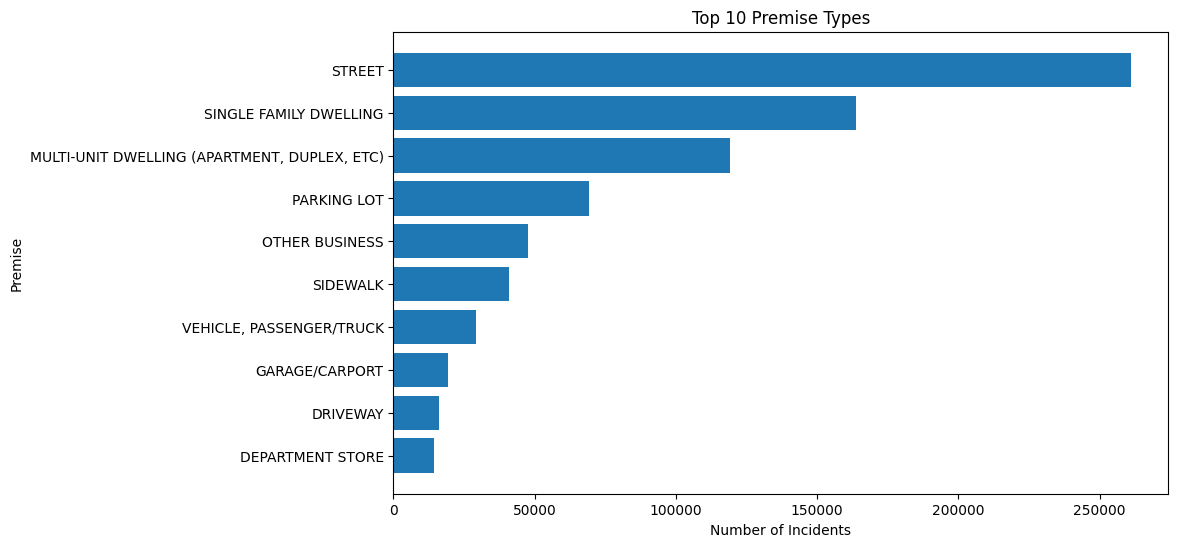

,Incidents
Premis Desc,
STREET,261261
SINGLE FAMILY DWELLING,163650
"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",119010
PARKING LOT,69142
OTHER BUSINESS,47646
SIDEWALK,40861
"VEHICLE, PASSENGER/TRUCK",29300
GARAGE/CARPORT,19362
DRIVEWAY,16081


In [14]:
premises = df["Premis Desc"].fillna("Unknown").value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(premises.index, premises.values)
plt.title("Top 10 Premise Types")
plt.xlabel("Number of Incidents")
plt.ylabel("Premise")
plt.show()

display(premises.sort_values(ascending=False).to_frame("Incidents"))


## 11. Weapon Analysis

,Records
Weapon information recorded,327216
Weapon information missing,677678


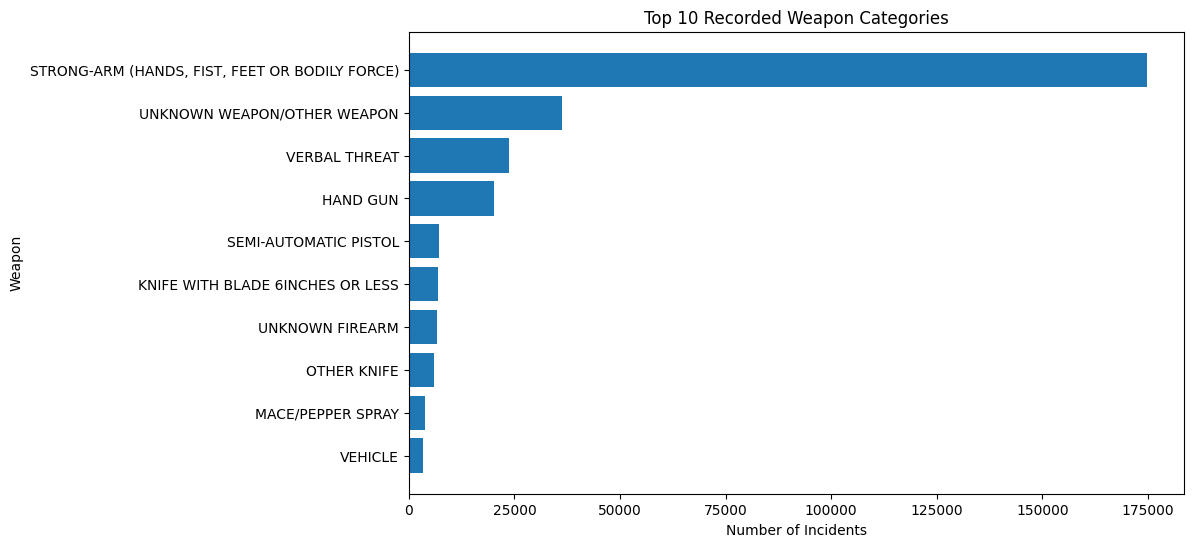

,Incidents
Weapon Desc,
"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",174739
UNKNOWN WEAPON/OTHER WEAPON,36387
VERBAL THREAT,23842
HAND GUN,20182
SEMI-AUTOMATIC PISTOL,7267
KNIFE WITH BLADE 6INCHES OR LESS,6837
UNKNOWN FIREARM,6582
OTHER KNIFE,5879
MACE/PEPPER SPRAY,3730


In [15]:
weapon_known = df["Weapon Desc"].notna().sum()
weapon_unknown = df["Weapon Desc"].isna().sum()

display(pd.Series({
    "Weapon information recorded": weapon_known,
    "Weapon information missing": weapon_unknown
}).to_frame("Records"))

top_weapons = df["Weapon Desc"].dropna().value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_weapons.index, top_weapons.values)
plt.title("Top 10 Recorded Weapon Categories")
plt.xlabel("Number of Incidents")
plt.ylabel("Weapon")
plt.show()

display(top_weapons.sort_values(ascending=False).to_frame("Incidents"))


## 12. Crime Type by Police Area

In [ ]:
top_crime_names = df["Crm Cd Desc"].value_counts().head(5).index
top_area_names = df["AREA NAME"].value_counts().head(10).index

cross_tab = pd.crosstab(df["AREA NAME"], df["Crm Cd Desc"])
selected = cross_tab.loc[
    cross_tab.index.intersection(top_area_names),
    cross_tab.columns.intersection(top_crime_names)
]

display(selected)


## 13. Key Findings

In [16]:
top_year = int(yearly.idxmax())
top_year_count = int(yearly.max())
top_crime = df["Crm Cd Desc"].value_counts().idxmax()
top_crime_count = int(df["Crm Cd Desc"].value_counts().max())
top_area = df["AREA NAME"].value_counts().idxmax()
top_area_count = int(df["AREA NAME"].value_counts().max())
top_period = period_counts.idxmax()
top_period_count = int(period_counts.max())

print(f"1. The dataset contains {len(df):,} recorded incidents.")
print(f"2. The highest recorded incident count occurs in {top_year}: {top_year_count:,} incidents.")
print(f"3. The most frequent crime category is '{top_crime}': {top_crime_count:,} incidents.")
print(f"4. The police area with the highest recorded incident count is '{top_area}': {top_area_count:,} incidents.")
print(f"5. The time-of-day category with the highest recorded incident count is '{top_period}': {top_period_count:,} incidents.")
print(f"6. The median valid victim age is {valid_age.median():.0f} years.")


1. The dataset contains 1,004,894 recorded incidents.
2. The highest recorded incident count occurs in 2022: 235,259 incidents.
3. The most frequent crime category is 'VEHICLE - STOLEN': 115,184 incidents.
4. The police area with the highest recorded incident count is 'Central': 69,668 incidents.
5. The time-of-day category with the highest recorded incident count is 'Night': 278,552 incidents.
6. The median valid victim age is 30 years.
